In [1]:
import json
import pandas as pd
from PIL import Image
import os

# Извлекаю аннотации из json-файла
with open('output/all_results.json', 'r', encoding='utf-8') as f:
    json_data = json.load(f)['results']


def parse_anns(ann):
    # В данных есть артефакты, поэтому через исключения
    try:
        ann_str = ann.replace('```json\n', '').replace('\n```', '')
        return json.loads(ann_str)
    except:
        return None

output_df_f = 'output/annotations.pkl'

# Выполняю компоновку датафрейма или загружаю из файла
if os.path.exists(output_df_f):
    df = pd.read_pickle(output_df_f)
else:
    annotations = []
    for f_name, ann in json_data.items():
        if ann['status'] == 'success':
            f_ann = parse_anns(ann['prediction'])
            if f_ann:
                img_path = os.path.join('data/img/', f_name)
                if os.path.exists(img_path):
                    img = Image.open(img_path)
                    annotations.append({
                        'photo_id': f_name,
                        'type': f_ann.get('building_type'),
                        'type_alt': f_ann.get('alternate_building_type'),
                        'age': f_ann.get('building_age'),
                        'surface_mat': f_ann.get('surface_material'),
                        'surface_mat_alt': f_ann.get('alternate_surface_material'),
                        'constr_mat': f_ann.get('construction_material'),
                        'constr_mat_alt': f_ann.get('alternate_construction_material'),
                        'floors': f_ann.get('floors'),
                        'img_width': img.width,
                        'img_height': img.height,
                        'wh_ratio': round(img.width / img.height, 2),
                        'filepath': img_path
                    })
    df = pd.DataFrame(annotations)
    df[['age', 'floors']] = df[['age', 'floors']].astype(int)
    df.to_pickle(output_df_f)
    
df.head(5)

,photo_id,type,type_alt,age,surface_mat,surface_mat_alt,constr_mat,constr_mat_alt,floors,img_width,img_height,wh_ratio,filepath
0,1093881547883011_740121.jpg,office,education,2023,glass,metal,steel,concrete,5,739,574,1.29,data/img/1093881547883011_740121.jpg
1,1007001623840957_740923.jpg,office,retail,1910,stone,plaster,stone,brick,4,707,884,0.80,data/img/1007001623840957_740923.jpg
2,1005857766484927_748849.jpg,industrial,retail,1980,metal,concrete,steel,concrete,2,1161,520,2.23,data/img/1005857766484927_748849.jpg
3,1101331527302990_879030.jpg,industrial,office,1970,brick,glass,steel,concrete,3,909,413,2.20,data/img/1101331527302990_879030.jpg
4,1194265617681155_752741.jpg,industrial,office,1990,metal,concrete,steel,concrete,2,891,392,2.27,data/img/1194265617681155_752741.jpg


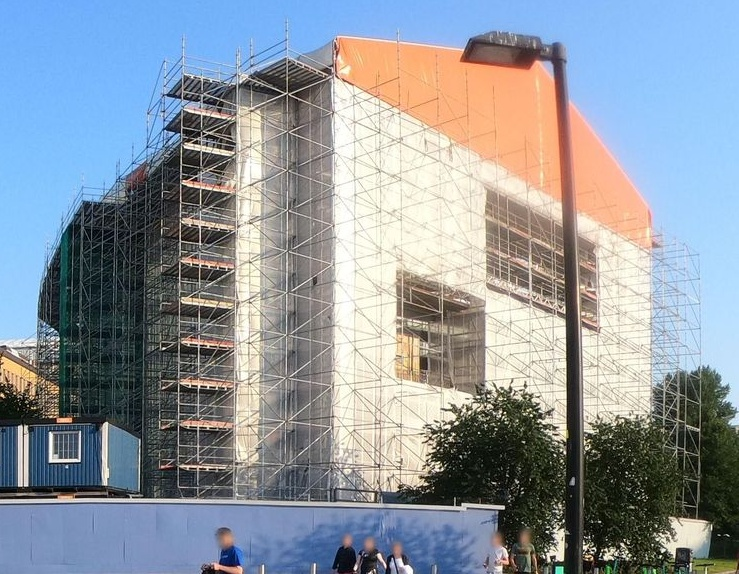

In [2]:
Image.open(df.iloc[0]['filepath']).show()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   photo_id         16921 non-null  object 
 1   type             16921 non-null  object 
 2   type_alt         16921 non-null  object 
 3   age              16921 non-null  int64  
 4   surface_mat      16921 non-null  object 
 5   surface_mat_alt  16921 non-null  object 
 6   constr_mat       16921 non-null  object 
 7   constr_mat_alt   16921 non-null  object 
 8   floors           16921 non-null  int64  
 9   img_width        16921 non-null  int64  
 10  img_height       16921 non-null  int64  
 11  wh_ratio         16921 non-null  float64
 12  filepath         16921 non-null  object 
dtypes: float64(1), int64(4), object(8)
memory usage: 1.7+ MB


In [4]:
df.shape

(16921, 13)

In [5]:
# Пропусков не будет, тк они все отвалились при разборе json'а
print(df.isnull().sum())

photo_id           0
type               0
type_alt           0
age                0
surface_mat        0
surface_mat_alt    0
constr_mat         0
constr_mat_alt     0
floors             0
img_width          0
img_height         0
wh_ratio           0
filepath           0
dtype: int64


In [6]:
# Распределение типов зданий в %
type_counts = df['type'].value_counts()
total_images = len(df)

for b_type, count in type_counts.items():
    percentage = (count / total_images) * 100
    print(f"{b_type}: {count} ({percentage:.1f}%)")

print(f"\nВсего изображений: {total_images}")
print(f"Уникальных типов зданий: {df['type'].nunique()}")

apartments: 5229 (30.9%)
office: 2622 (15.5%)
house: 2414 (14.3%)
retail: 1835 (10.8%)
industrial: 1262 (7.5%)
education: 913 (5.4%)
public: 890 (5.3%)
hotel: 722 (4.3%)
religious: 694 (4.1%)
garage: 340 (2.0%)

Всего изображений: 16921
Уникальных типов зданий: 10


In [7]:
# Распределение по всем категориальным признакам и дисбаланс
categorical_cols = ['type', 'type_alt', 'surface_mat', 'surface_mat_alt', 'constr_mat', 'constr_mat_alt']
for col in categorical_cols:
    unique_values = df[col].unique()
    value_counts = df[col].value_counts()
    
    print(f"\n{col} - всего {len(unique_values)} уникальных значений:\n")
    
    for val in sorted(unique_values):
        count = value_counts[val]
        percentage = (count / total_images) * 100
        print(f"- {val}: {count} изображений ({percentage:.1f}%)")
    
    # Топ значение
    top_value = value_counts.index[0]
    top_count = value_counts.iloc[0]
    print(f"\nНаиболее частое значение: '{top_value}' - {top_count} изображений, {top_count/total_images*100:.1f}%")


type - всего 10 уникальных значений:

- apartments: 5229 изображений (30.9%)
- education: 913 изображений (5.4%)
- garage: 340 изображений (2.0%)
- hotel: 722 изображений (4.3%)
- house: 2414 изображений (14.3%)
- industrial: 1262 изображений (7.5%)
- office: 2622 изображений (15.5%)
- public: 890 изображений (5.3%)
- religious: 694 изображений (4.1%)
- retail: 1835 изображений (10.8%)

Наиболее частое значение: 'apartments' - 5229 изображений, 30.9%

type_alt - всего 11 уникальных значений:

- apartments: 2865 изображений (16.9%)
- education: 653 изображений (3.9%)
- garage: 1331 изображений (7.9%)
- hotel: 260 изображений (1.5%)
- house: 1314 изображений (7.8%)
- industrial: 423 изображений (2.5%)
- office: 3249 изображений (19.2%)
- public: 3426 изображений (20.2%)
- religious: 12 изображений (0.1%)
- retail: 3387 изображений (20.0%)
- stone: 1 изображений (0.0%)

Наиболее частое значение: 'public' - 3426 изображений, 20.2%

surface_mat - всего 8 уникальных значений:

- brick: 6174

Text(0.5, 1.0, 'Альтернативные типы зданий')

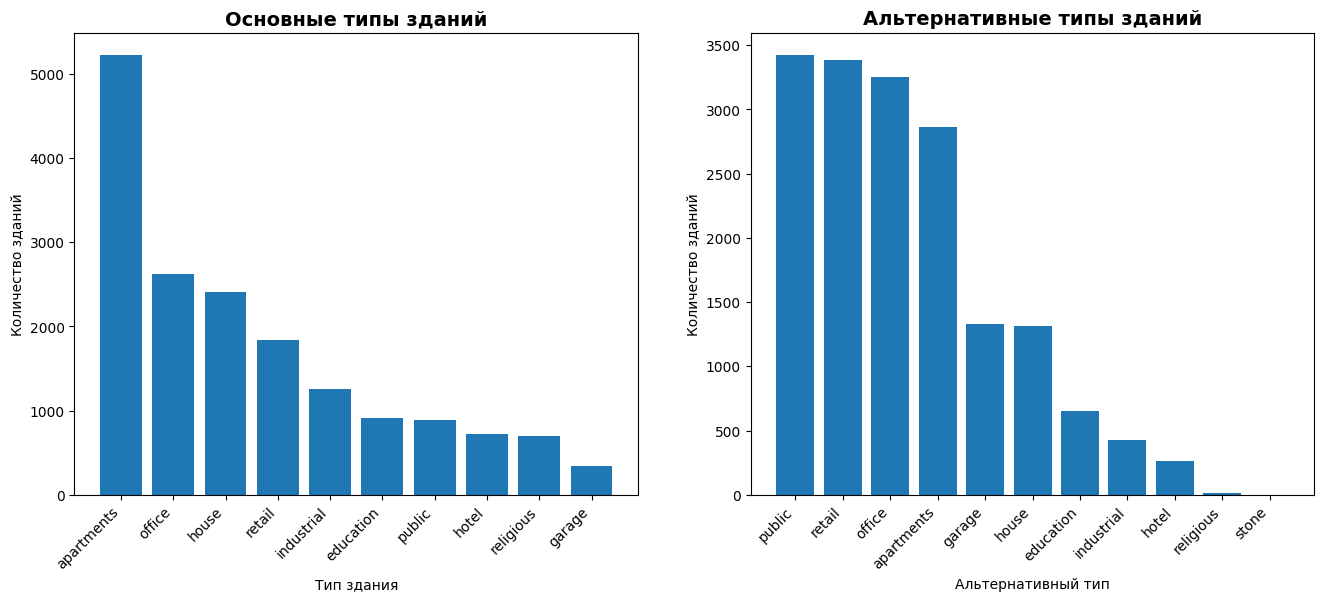

In [8]:
import matplotlib.pyplot as plt

# Распределение по типам зданий
type_cnt = df['type'].value_counts()
type_cnt_alt = df['type_alt'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(range(len(type_cnt)), type_cnt.values)
ax1.set_xticks(range(len(type_cnt)))
ax1.set_xticklabels(type_cnt.index, rotation=45, ha='right')
ax1.set_xlabel('Тип здания')
ax1.set_ylabel('Количество зданий')
ax1.set_title('Основные типы зданий', fontsize=14, fontweight='bold')

ax2.bar(range(len(type_cnt_alt)), type_cnt_alt.values)
ax2.set_xticks(range(len(type_cnt_alt)))
ax2.set_xticklabels(type_cnt_alt.index, rotation=45, ha='right')
ax2.set_xlabel('Альтернативный тип')
ax2.set_ylabel('Количество зданий')
ax2.set_title('Альтернативные типы зданий', fontsize=14, fontweight='bold')

Text(0.5, 1.0, 'Альтернативные материалы отделки')

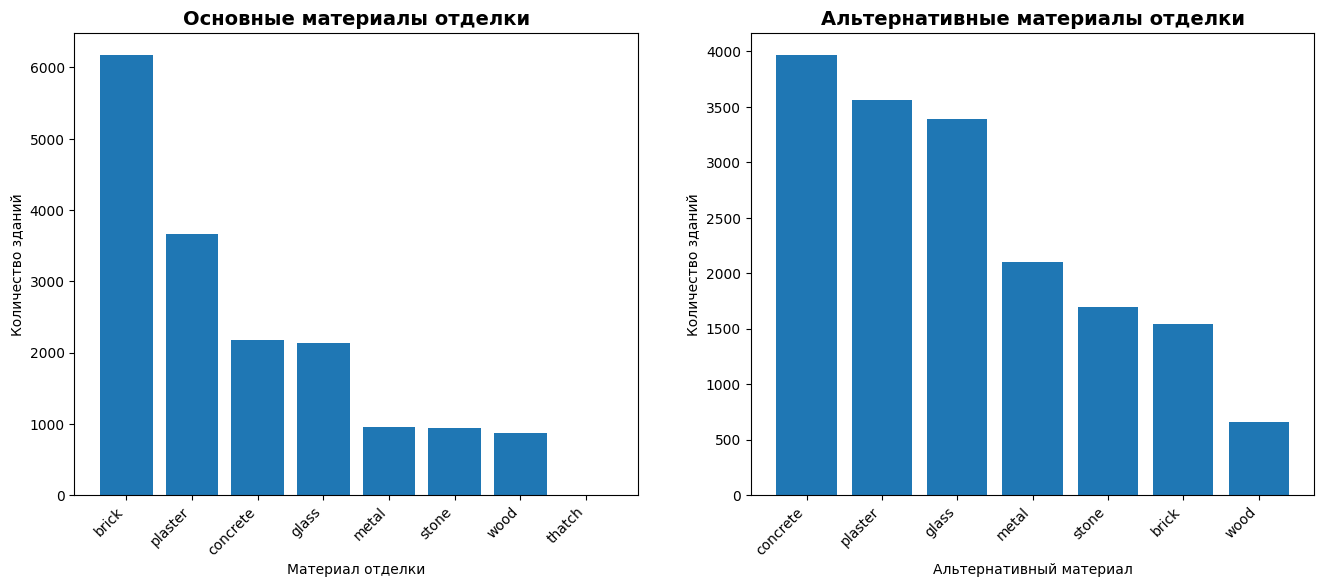

In [9]:
# Распределение по материалам наружней отделки
mat_cnt = df['surface_mat'].value_counts()
mat_cnt_alt = df['surface_mat_alt'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(range(len(mat_cnt)), mat_cnt.values)
ax1.set_xticks(range(len(mat_cnt)))
ax1.set_xticklabels(mat_cnt.index, rotation=45, ha='right')
ax1.set_xlabel('Материал отделки')
ax1.set_ylabel('Количество зданий')
ax1.set_title('Основные материалы отделки', fontsize=14, fontweight='bold')

ax2.bar(range(len(mat_cnt_alt)), mat_cnt_alt.values)
ax2.set_xticks(range(len(mat_cnt_alt)))
ax2.set_xticklabels(mat_cnt_alt.index, rotation=45, ha='right')
ax2.set_xlabel('Альтернативный материал')
ax2.set_ylabel('Количество зданий')
ax2.set_title('Альтернативные материалы отделки', fontsize=14, fontweight='bold')

In [10]:
# Посмотрю какая этажность наблюдается в датасете
df['floors'].unique()

array([  5,   4,   2,   3,   7,   6,   1,   8,  10,  15,  12,  18,  21,
        35,  25,   9,  46,  30,  20,  38,  14,  16,  22,  36,  61,  58,
        43,  24,  32,  23,  48,  11, 200,  40,  55,  50,  17,  26,  33,
        31,  29, 100,  56])

**Значения 100 и 200 этажей вполне могут быть артефактами. В ближайшие дни проведу ручную проверку/разметку датасета и посмотрю фото этих зданий.**

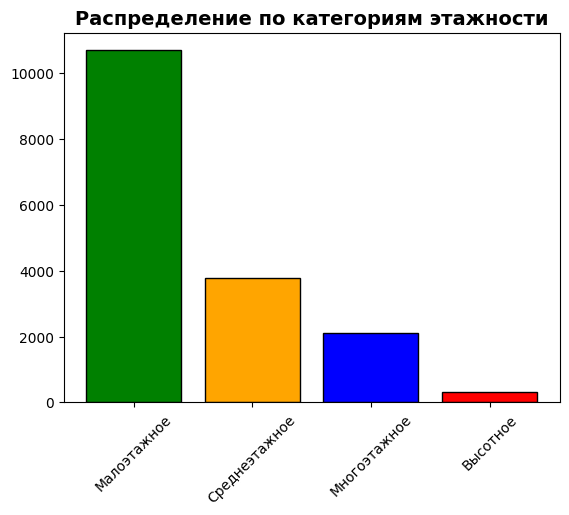

In [11]:
# Оценка категорий в соотвествии с классификации этажности в РФ
def floor_cat(floors):
    if floors <= 4:
        return 'Малоэтажное'
    elif floors > 4 and floors <= 8:
        return 'Среднеэтажное'
    elif floors > 8 and floors <= 25:
        return 'Многоэтажное'
    else:
        return 'Высотное'

df['floor_cat'] = df['floors'].apply(floor_cat)
cat_counts = df['floor_cat'].value_counts()
colors = ['green', 'orange', 'blue', 'red']
plt.bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='black')
plt.title('Распределение по категориям этажности', fontsize=14, fontweight='bold')
plt.tick_params(axis='x', rotation=45)

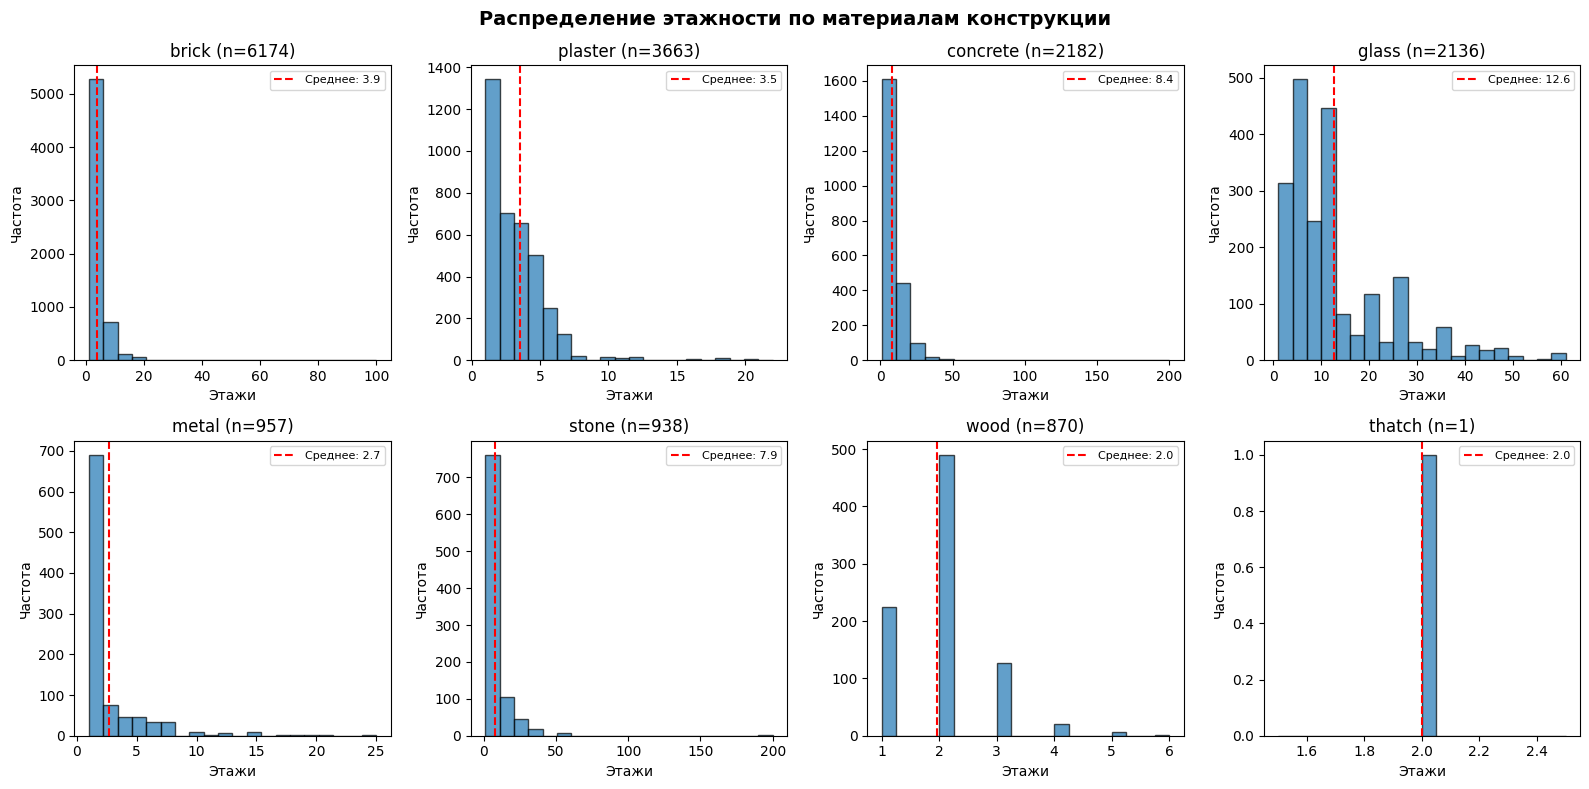

In [12]:
# Распределение этажности для разных материалов конструкции
mats = df['surface_mat'].value_counts().index

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, mat in enumerate(mats):
    subset = df[df['surface_mat'] == mat]['floors']
    axes[i].hist(subset, bins=20, edgecolor='black', alpha=0.7)
    axes[i].axvline(subset.mean(), color='red', ls='--', label=f'Среднее: {subset.mean():.1f}')
    axes[i].set_title(f'{mat} (n={len(subset)})')
    axes[i].set_xlabel('Этажи')
    axes[i].set_ylabel('Частота')
    axes[i].legend(fontsize=8)

plt.suptitle('Распределение этажности по материалам конструкции', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Топ-10 типов зданий по средней этажности')

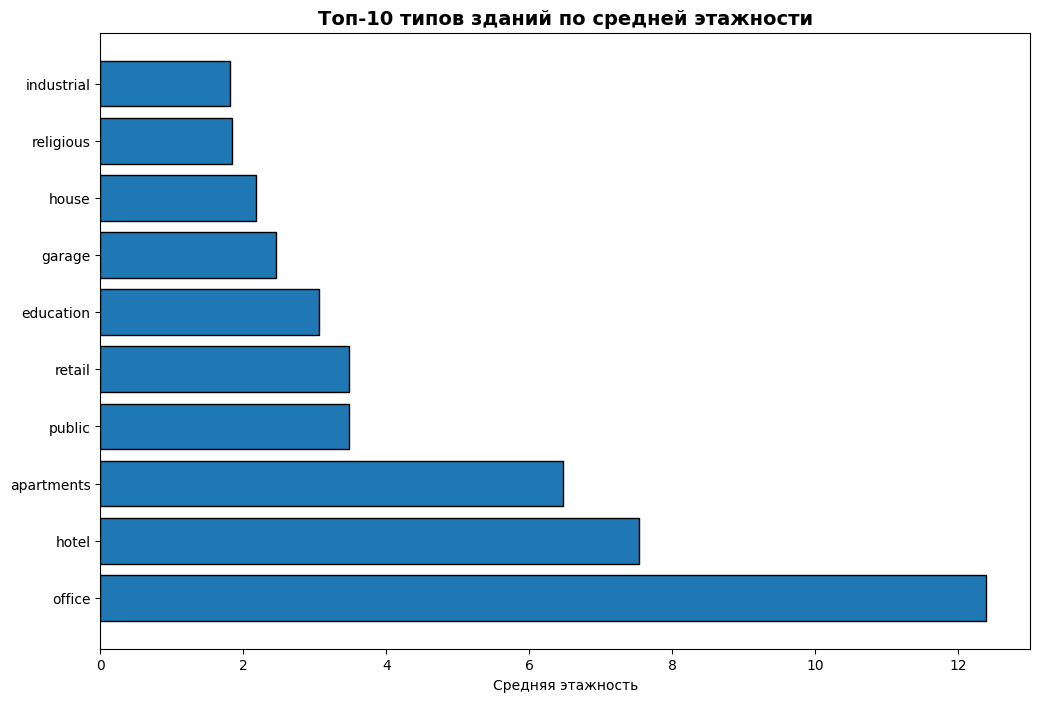

In [13]:
# Средняя этажность в зависимости от типа здания
mean_floors_by_type = df.groupby('type')['floors'].agg(['mean', 'count', 'std']).round(2)
mean_floors_by_type = mean_floors_by_type.sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(mean_floors_by_type)), mean_floors_by_type['mean'].values, edgecolor='black')
plt.yticks(range(len(mean_floors_by_type)), mean_floors_by_type.index)
plt.xlabel('Средняя этажность')
plt.title('Топ-10 типов зданий по средней этажности', fontsize=14, fontweight='bold')

In [14]:
# Средний год постройки по материалу здания
print("Материалы отделки по году постройки")
mean_age_mat = df.groupby('surface_mat')['age'].agg(['mean', 'count']).sort_values('mean')
for mat, row in mean_age_mat.iterrows():
    print(f"- {mat}, средний год постройки: {row['mean']:.0f}, построек: {int(row['count'])};")

Материалы отделки по году постройки
- stone, средний год постройки: 1915, построек: 938;
- brick, средний год постройки: 1933, построек: 6174;
- plaster, средний год постройки: 1947, построек: 3663;
- wood, средний год постройки: 1955, построек: 870;
- concrete, средний год постройки: 1980, построек: 2182;
- metal, средний год постройки: 1993, построек: 957;
- glass, средний год постройки: 1996, построек: 2136;
- thatch, средний год постройки: 2000, построек: 1;


Text(0.5, 1.0, 'Форматы изображений')

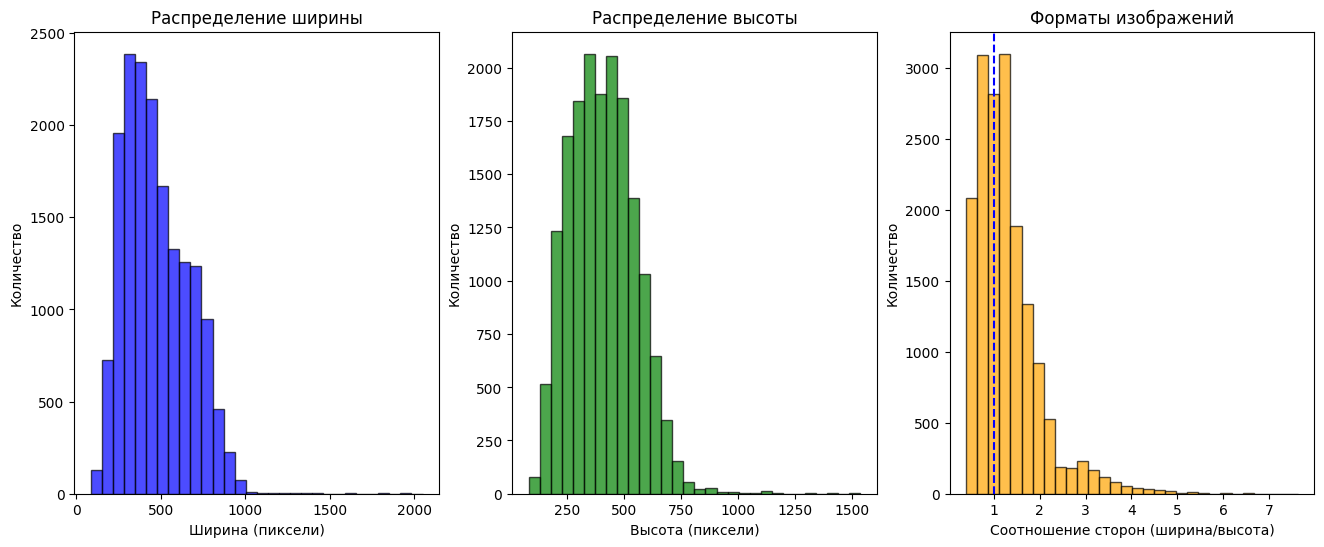

In [15]:
# Параметры размера самих изображений
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

ax1.hist(df['img_width'], bins=30, edgecolor='black', alpha=0.7, color='blue')
ax1.set_xlabel('Ширина (пиксели)')
ax1.set_ylabel('Количество')
ax1.set_title('Распределение ширины')

ax2.hist(df['img_height'], bins=30, edgecolor='black', alpha=0.7, color='green')
ax2.set_xlabel('Высота (пиксели)')
ax2.set_ylabel('Количество')
ax2.set_title('Распределение высоты')

ax3.hist(df['wh_ratio'], bins=30, edgecolor='black', alpha=0.7, color='orange')
ax3.axvline(1.0, color='blue', ls='--')
ax3.set_xlabel('Соотношение сторон (ширина/высота)')
ax3.set_ylabel('Количество')
ax3.set_title('Форматы изображений')

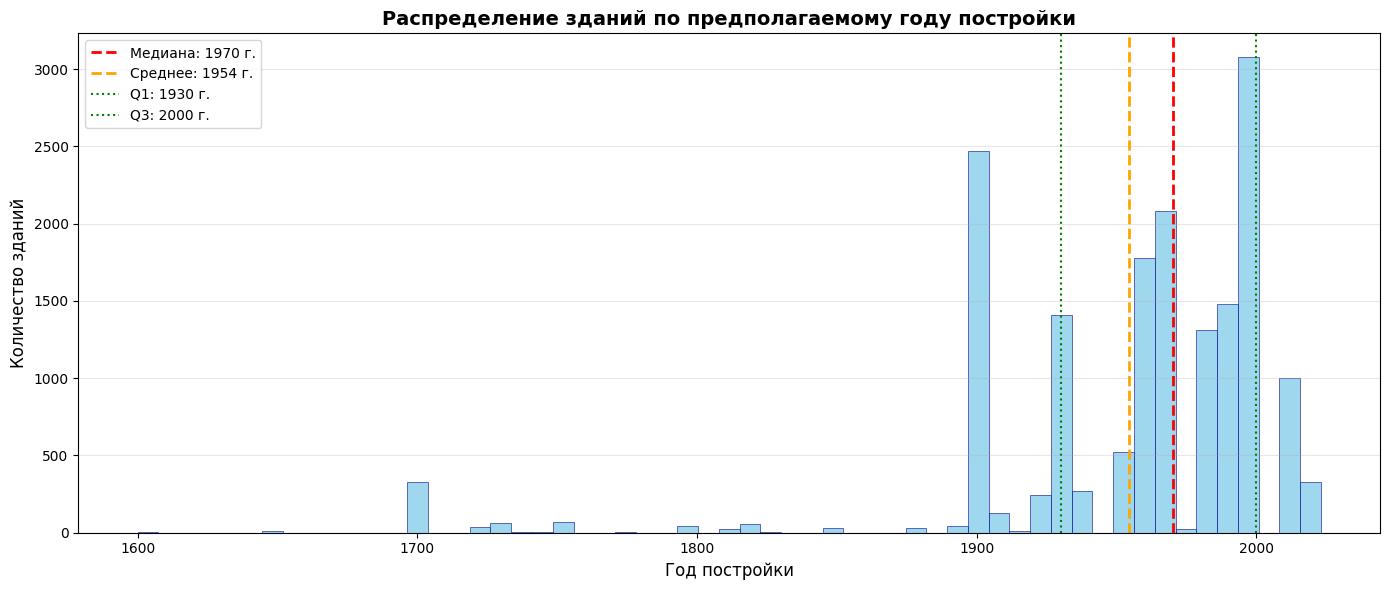

In [16]:
# Беру год после 1600 для улучшения читаемости
df_filtered = df[df['age'] >= 1600]

fig, ax = plt.subplots(figsize=(14, 6))

n_bins = min(80, df_filtered['age'].nunique())
n, bins, patches = ax.hist(
    df_filtered['age'],
    bins=n_bins,
    color='skyblue',
    edgecolor='darkblue',
    alpha=0.8,
    linewidth=0.5
)

# Статистика
median_val = df_filtered['age'].median()
mean_val = df_filtered['age'].mean()
q1_val = df_filtered['age'].quantile(0.25)
q3_val = df_filtered['age'].quantile(0.75)

ax.axvline(median_val, color='red', linestyle='--', linewidth=2, 
           label=f'Медиана: {median_val:.0f} г.')
ax.axvline(mean_val, color='orange', linestyle='--', linewidth=2, 
           label=f'Среднее: {mean_val:.0f} г.')
ax.axvline(q1_val, color='green', linestyle=':', linewidth=1.5, 
           label=f'Q1: {q1_val:.0f} г.')
ax.axvline(q3_val, color='green', linestyle=':', linewidth=1.5, 
           label=f'Q3: {q3_val:.0f} г.')

# Настройка подписей
ax.set_xlabel('Год постройки', fontsize=12)
ax.set_ylabel('Количество зданий', fontsize=12)
ax.set_title(
    'Распределение зданий по предполагаемому году постройки',
    fontsize=14,
    fontweight='bold'
)
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()